In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

In [10]:
# ── Load cleaned dataset ───────────────────────────────
df = pd.read_csv('sales_cleaned.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Ensure date columns exist
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter']    = df['Order Date'].dt.quarter

MONTH_ORDER = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded 9,326 rows × 29 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,Year,Month,Month Name,Quarter,Day of Week,Profit Margin %,Revenue per Unit,Is Profitable
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.0,41.9136,2016,11,November,4,Tuesday,16.0,130.98,True
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.0,219.5820,2016,11,November,4,Tuesday,30.0,243.98,True
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.0,6.8714,2016,6,June,2,Sunday,47.0,7.31,True


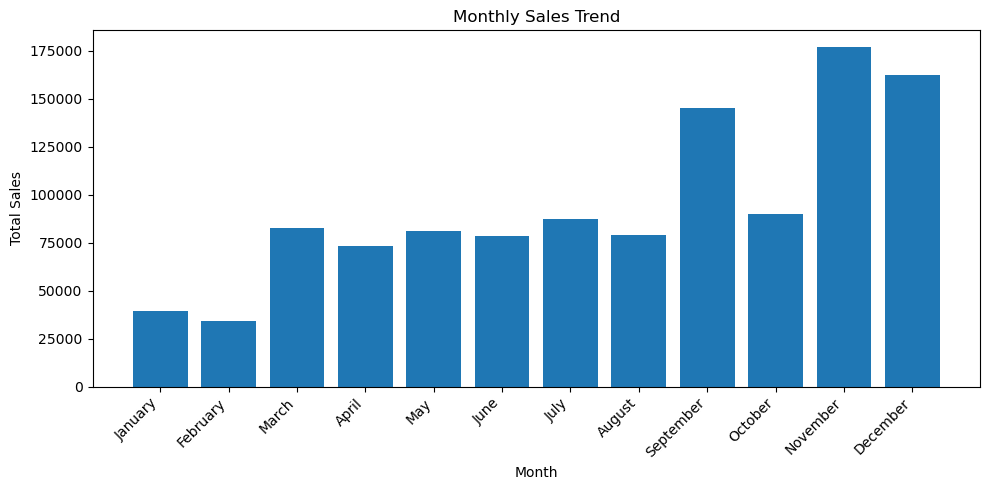

Saved → images/chart1_monthly_trend.png


In [11]:
# ── Aggregate ──────────────────────────────────────────
monthly = (
    df.groupby('Month Name')['Sales']
      .sum()
      .reindex(MONTH_ORDER)
      .reset_index()
)
monthly.columns = ['Month', 'Sales']

# ── Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(monthly['Month'], monthly['Sales'])

ax.set_title('Monthly Sales Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Month'], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('images/chart1_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/chart1_monthly_trend.png')

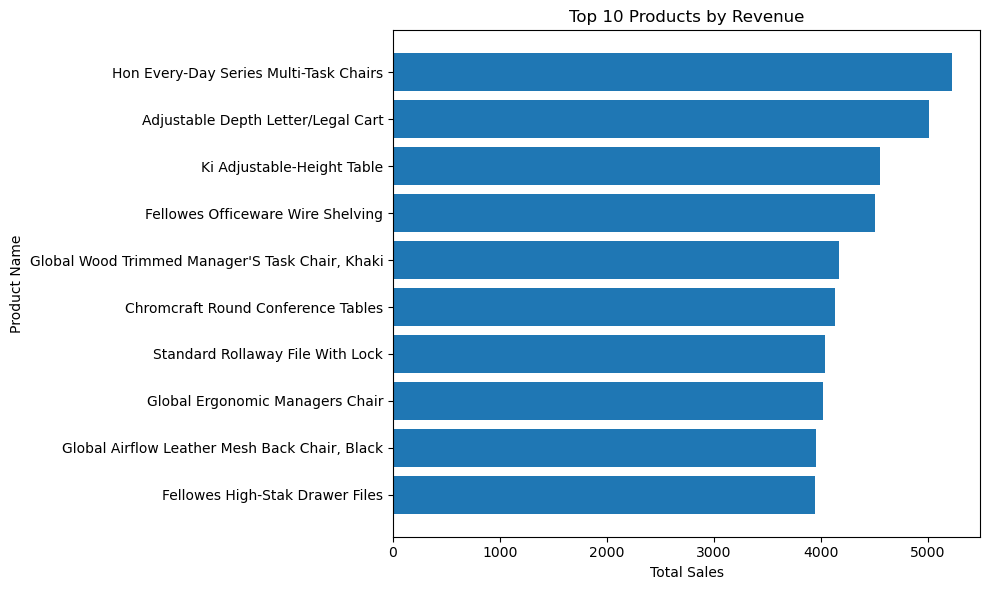

Saved → images/chart2_top10_products.png


In [12]:
# ── Aggregate ──────────────────────────────────────────
top10 = (
    df.groupby('Product Name')
      .agg(Sales=('Sales','sum'))
      .sort_values('Sales', ascending=False)
      .head(10)
      .reset_index()
)
top10 = top10.sort_values('Sales', ascending=True)  # flip for horizontal bar

# ── Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top10['Product Name'], top10['Sales'])

ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Total Sales')
ax.set_ylabel('Product Name')

plt.tight_layout()
plt.savefig('images/chart2_top10_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/chart2_top10_products.png')

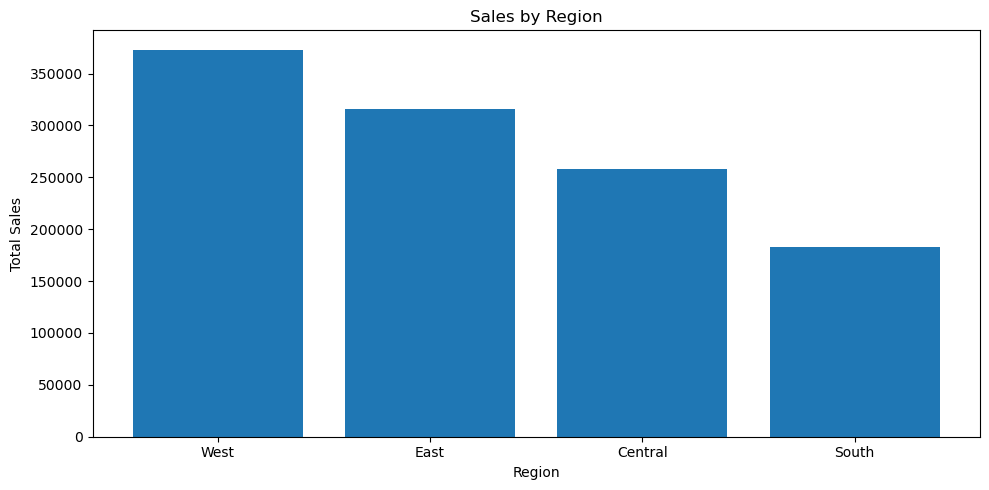

Saved → images/chart3_region_sales.png


In [13]:
# ── Aggregate ──────────────────────────────────────────
region = (
    df.groupby('Region')
      .agg(Sales=('Sales','sum'))
      .sort_values('Sales', ascending=False)
      .reset_index()
)

# ── Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(region['Region'], region['Sales'])

ax.set_title('Sales by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales')

plt.tight_layout()
plt.savefig('images/chart3_region_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/chart3_region_sales.png')

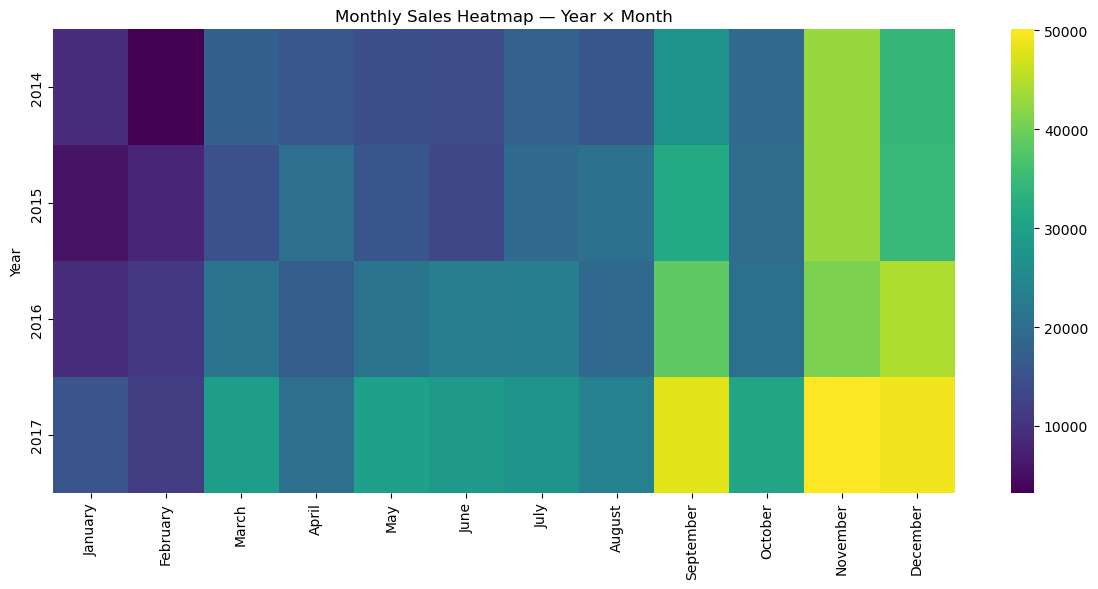

Saved → images/chart4_heatmap.png


In [14]:
# ── Pivot table: rows = Year, columns = Month ──────────
heatmap_data = (
    df.groupby(['Year', 'Month Name'])['Sales']
      .sum()
      .reset_index()
      .pivot(index='Year', columns='Month Name', values='Sales')
      .reindex(columns=MONTH_ORDER)
)

# ── Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(heatmap_data, cmap='viridis', ax=ax)

ax.set_title('Monthly Sales Heatmap — Year × Month')
ax.set_xlabel('')
ax.set_ylabel('Year')

plt.tight_layout()
plt.savefig('images/chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/chart4_heatmap.png')

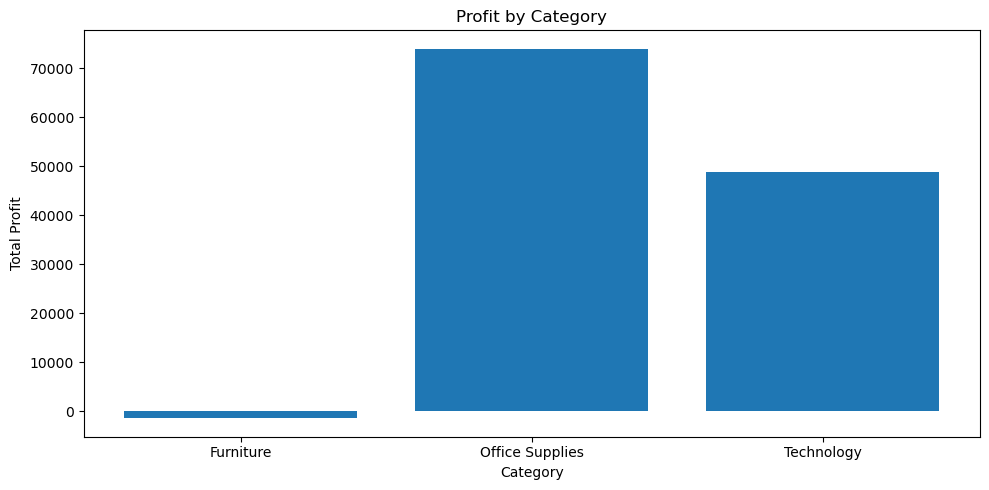

In [ ]:
# ── Aggregate ──────────────────────────────────────────
cat = (
    df.groupby('Category')
      .agg(Profit=('Profit','sum'))
      .reset_index()
)

# ── Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(cat['Category'], cat['Profit'])

ax.set_title('Profit by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Total Profit')

plt.tight_layout()
plt.savefig('images/chart5_profit_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/chart5_profit_category.png')